# Saliency — What Does the CNN Focus On?

Vanilla gradient saliency: for each species, which RT bins and m/z channels most influence the model's prediction? Computed as ∂(class score)/∂(input chromatogram), averaged over correctly-classified samples.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..').resolve()))
import chroma_dcnn; sys.modules.setdefault('msformer', chroma_dcnn)
import chroma_dcnn.models, chroma_dcnn.training

from chroma_dcnn.models.chroma_cnn import ChromatogramCNN, ChromaCNNConfig

DATA_DIR  = Path('../data/fish_oil')
CKPT_PATH = Path('../checkpoints/chroma_pretrain/best.pt')
DEVICE    = torch.device('cpu')

SPECIES = {0: 'SNA (Snapper)', 1: 'GUR (Gurnard)', 2: 'TAR (Tarakihi)', 3: 'BCO (Blue Cod)'}
COLOURS = {0: '#2196f3', 1: '#ff9800', 2: '#4caf50', 3: '#e91e63'}

y = np.load(DATA_DIR / 'y.npy')
npz_paths = sorted((DATA_DIR / 'chroma').glob('*.npz'))
chromas   = np.stack([np.load(p)['chroma'] for p in npz_paths])  # [N, 200, 1000]
print(f'Loaded {len(chromas)} chromatograms')

Loaded 103 chromatograms


In [2]:
# ── Train one fold of the pretrained classifier ───────────────────────────────
torch.manual_seed(0)
np.random.seed(0)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
tr_idx, te_idx = next(skf.split(chromas, y))

X_tr = torch.tensor(chromas[tr_idx], dtype=torch.float32)
y_tr = torch.tensor(y[tr_idx],       dtype=torch.long)
X_te = torch.tensor(chromas[te_idx], dtype=torch.float32)
y_te = y[te_idx]

cfg   = ChromaCNNConfig(mz_max=1000, cnn_channels=128, kernel_size=7, num_classes=4, dropout=0.3)
model = ChromatogramCNN(cfg).to(DEVICE)
model.load_pretrained_chroma_encoder(str(CKPT_PATH))

opt       = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
loader    = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_tr, y_tr), batch_size=16, shuffle=True)

model.train()
for epoch in range(80):
    for xb, yb in loader:
        opt.zero_grad()
        criterion(model(xb), yb).backward()
        opt.step()

model.eval()
with torch.no_grad():
    preds = model(X_te).argmax(dim=1).numpy()

from sklearn.metrics import balanced_accuracy_score
ba = balanced_accuracy_score(y_te, preds)
print(f'Fold BA: {ba:.3f}')

  Loaded pretrained spec_proj from ../checkpoints/chroma_pretrain/best.pt
  Loaded pretrained CNN from ../checkpoints/chroma_pretrain/best.pt


Fold BA: 0.725


In [3]:
# ── Vanilla gradient saliency ─────────────────────────────────────────────────
saliency = {c: [] for c in range(4)}

model.eval()
for i in range(len(chromas)):
    c = int(y[i])
    x = torch.tensor(chromas[i:i+1], dtype=torch.float32, requires_grad=True)
    logits = model(x)
    logits[0, c].backward()
    grad = x.grad.detach().abs().squeeze(0).numpy()  # [200, 1000]
    saliency[c].append(grad)

saliency_mean = {c: np.stack(saliency[c]).mean(axis=0) for c in range(4)}
print('Saliency maps computed for each species.')

Saliency maps computed for each species.


## Per-species saliency heatmaps (RT × m/z)

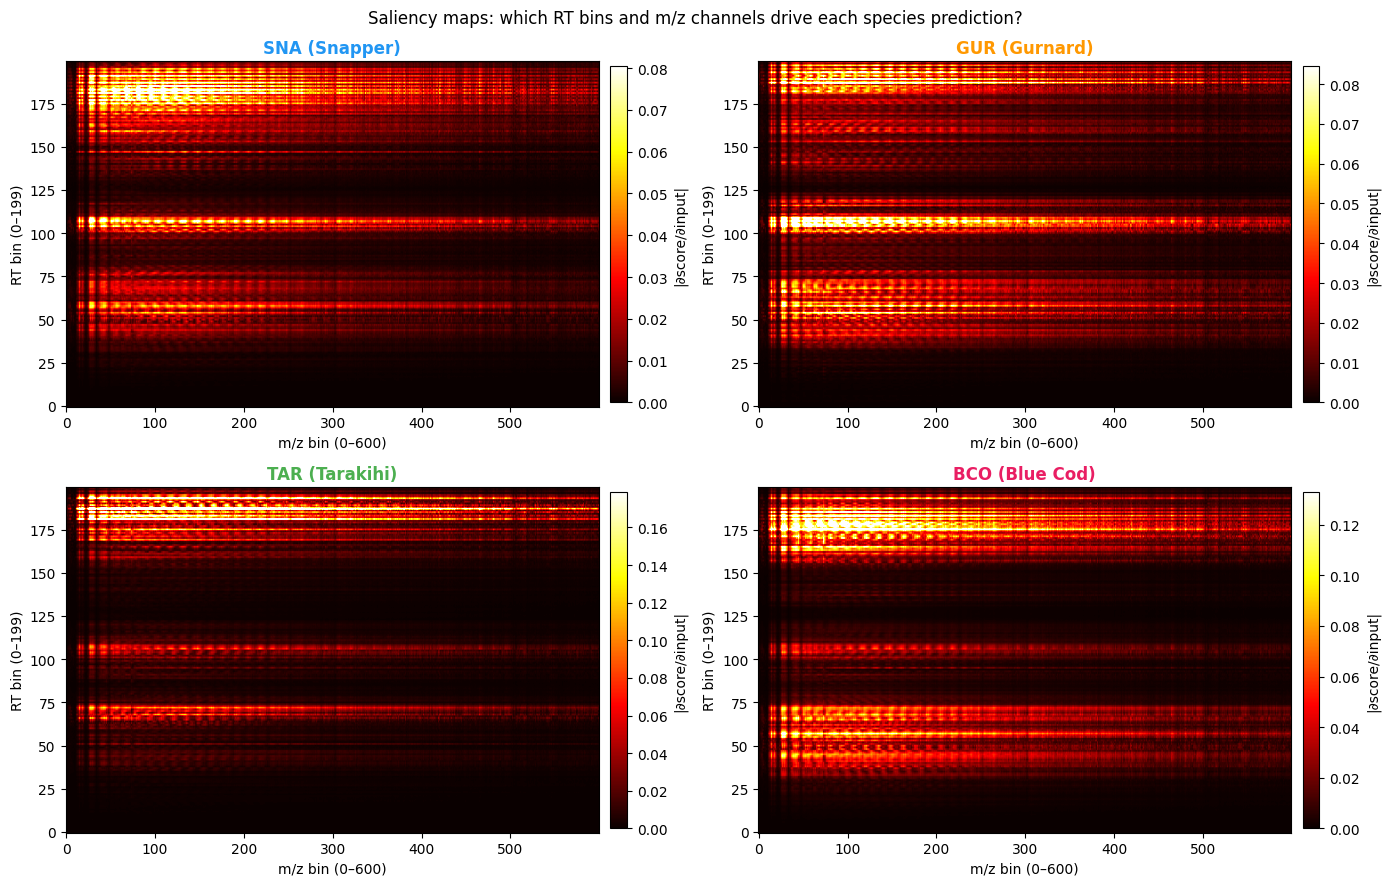

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for c, ax in enumerate(axes):
    sal = saliency_mean[c][:, :600]    # crop m/z > 600 (low signal)
    # Percentile normalise for display
    vmax = np.percentile(sal, 99)
    im = ax.imshow(sal, aspect='auto', origin='lower',
                   cmap='hot', vmin=0, vmax=vmax)
    ax.set_title(SPECIES[c], color=COLOURS[c], fontweight='bold')
    ax.set_xlabel('m/z bin (0–600)')
    ax.set_ylabel('RT bin (0–199)')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='|∂score/∂input|')

plt.suptitle('Saliency maps: which RT bins and m/z channels drive each species prediction?',
             fontsize=12)
plt.tight_layout()
plt.show()

## Marginal saliency: RT profile and m/z profile per species

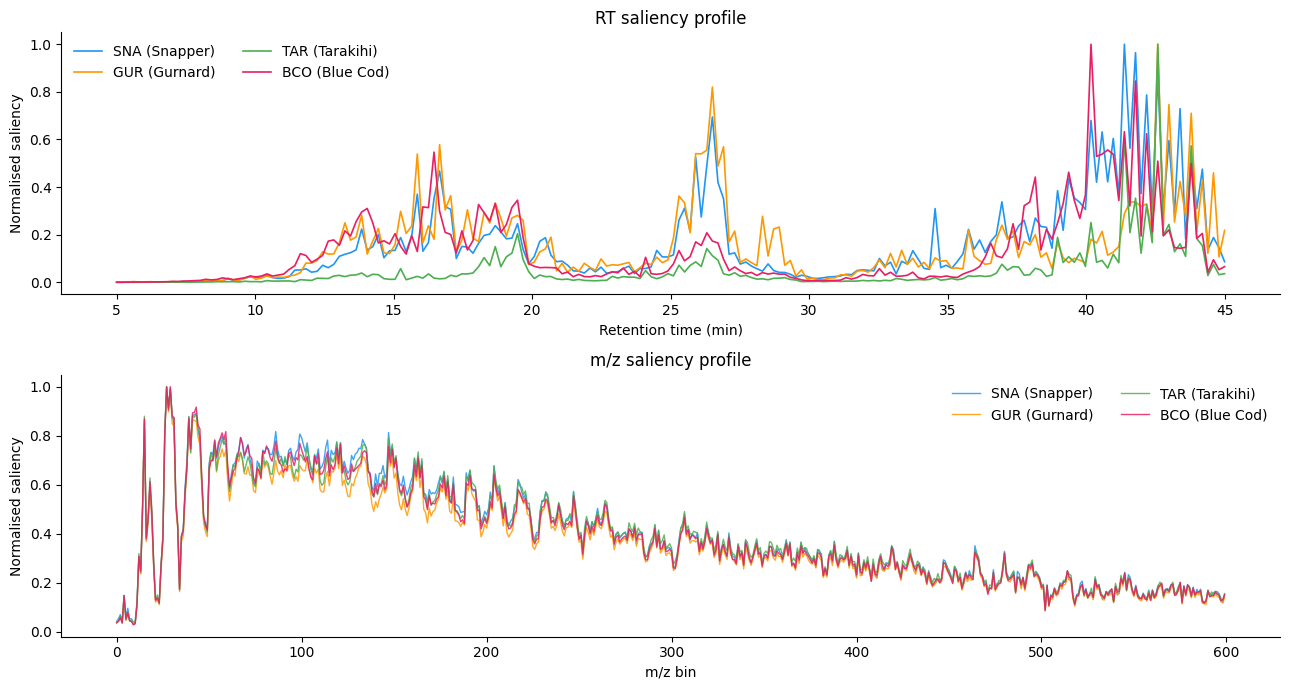

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# RT marginal (mean over m/z axis)
rt_vals = np.linspace(5, 45, 200)
for c in range(4):
    rt_sal = saliency_mean[c].mean(axis=1)
    axes[0].plot(rt_vals, rt_sal / rt_sal.max(),
                 color=COLOURS[c], label=SPECIES[c], linewidth=1.2)
axes[0].set_xlabel('Retention time (min)')
axes[0].set_ylabel('Normalised saliency')
axes[0].set_title('RT saliency profile')
axes[0].legend(frameon=False, ncol=2)
sns.despine(ax=axes[0])

# m/z marginal (mean over RT axis)
for c in range(4):
    mz_sal = saliency_mean[c].mean(axis=0)[:600]
    axes[1].plot(np.arange(600), mz_sal / mz_sal.max(),
                 color=COLOURS[c], label=SPECIES[c], linewidth=1.0, alpha=0.85)
axes[1].set_xlabel('m/z bin')
axes[1].set_ylabel('Normalised saliency')
axes[1].set_title('m/z saliency profile')
axes[1].legend(frameon=False, ncol=2)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()